In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
documents = [
    "The basic thing to consider when building a quadruped robot is the issue of balance. These factors greatly determine the success of the quadruped robot in carrying out movements such as stabilizing the body on an inclined plane, walking movements and others. Conventional feedback control methods by performing mathematical modeling can be used to balance the robot. However, this method still has weaknesses. The application of conventional feedback control methods often results in an inaccurate controller, so it must be manually tuned for its application. In this study, reinforcement learning methods were used using Q-Learning algorithms. The use of reinforcement learning methods was chosen because no mathematical calculations are needed to control the balance of quadruped robots. The process of learning the system to train the agent's abilities is carried out using a Gazebo simulator. The learning results show that the system could run well as evidenced by the higher value of sum rewards per episode.",
    "Forest has an important role on earth. The need to monitor forest from illegal activities and the types of animals in there is needed to keep the forest in good condition. However, the condition of the vast forest and limited resource make direct forest monitoring by officer (human) is limited. In this case, sound with digital signal processing can be used as a tool for forest monitoring. In this study, a system was implemented to classify sound on the Raspberry Pi 3B+ using mel-spectrogram. Sounds that classified are the sound of chainsaw, gunshot, and the sound of 8 species of bird. This study also compared pretrained VGG-16 and MobileNetV3 as feature extractor, and several classification methods, namely Random Forest, SVM, KNN, and MLP. To vary and increase the number of training data, we used several types of data augmentation, namely add noise, time stretch, time shift, and pitch shift. Based on the result of this study, it was found that the MobileNetV3-Small + MLP model with combined training data from time stretch and time shift augmentation provide the best performance to be implemented in this system, with an inference duration of 0.8 seconds; 93.96% accuracy; and 94.1% precision.",
    "The process of packing food products manually raises many problems, including inefficiency, quality of hygiene, changing the composition according to market demand, and monitoring, that are difficult to do remotely in real-time. This research builds SCADA for filling and packing Multi-grain rice packages containing 2-3 kinds of grains. The composition of the grain be filled in the package through the HMI. The conveyor moves to carry the packing bags and stops at each grain container. The rotary vane feeder of the container will rotate so that the packaging bag will be filled with grains and then glued together. The position of the packaging bag is detected by 3 pairs of photosensors. The actuator control uses a Schneider M221 PLC via ethernet port. The communication system between the I/O devices and the PLC uses a cable, while the communication between the PLC and the HMI is via the internet network. The system is capable of filling the material according to the desired composition, sealing, and packing to the number of packages. HMI feeds composition input to the system, displays animations correctly, raises an alarm when the material in the tub is running low, and  record production as a daily report."
]

## https://jurnal.ugm.ac.id/ijeis/article/view/73865
## https://jurnal.ugm.ac.id/ijeis/article/view/79536
## https://jurnal.ugm.ac.id/ijeis/article/view/72708


=== Document-Term Matrix using CountVectorizer ===
            16  3b  93  94  96  abilities  according  accuracy  activities  \
Abstract 1   0   0   0   0   0          1          0         0           0   
Abstract 2   1   1   1   1   1          0          0         1           1   
Abstract 3   0   0   0   0   0          0          2         0           0   

            actuator  ...  used  uses  using  value  vane  vary  vast  vgg  \
Abstract 1         0  ...     2     0      2      1     0     0     0    0   
Abstract 2         0  ...     2     0      1      0     0     1     1    1   
Abstract 3         1  ...     0     2      0      0     1     0     0    0   

            walking  weaknesses  
Abstract 1        1           1  
Abstract 2        0           0  
Abstract 3        0           0  

[3 rows x 215 columns]


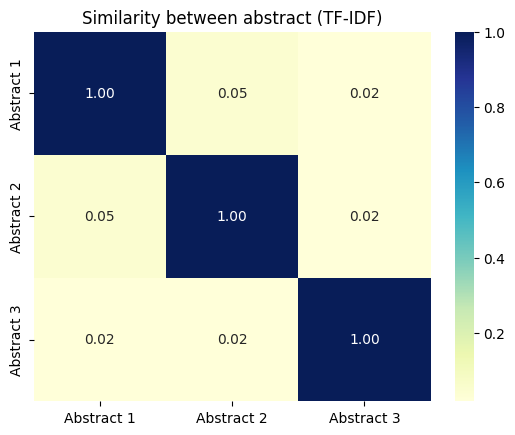

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
count_vectorizer = CountVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)
sparse_matrix = count_vectorizer.fit_transform(documents)

cos_sim = cosine_similarity(tfidf_matrix)
doc_term_matrix = sparse_matrix.todense()

doc_term_matrix = sparse_matrix.todense()

labels = ['Abstract 1', 'Abstract 2', 'Abstract 3']
sns.heatmap(cos_sim, annot=True, xticklabels=labels, yticklabels=labels, cmap="YlGnBu", fmt=".2f")

df = pd.DataFrame(
    doc_term_matrix,
    columns=count_vectorizer.get_feature_names_out(),
    index=labels
)

print("\n=== Document-Term Matrix using CountVectorizer ===")
print(df)

plt.title("Similarity between abstract (TF-IDF)")
plt.show()


=== Document-Term Matrix using CountVectorizer ===
            16  3b  93  94  96  abilities  according  accuracy  activities  \
Abstract 1   0   0   0   0   0          1          0         0           0   
Abstract 2   1   1   1   1   1          0          0         1           1   
Abstract 3   0   0   0   0   0          0          2         0           0   

            actuator  ...  used  uses  using  value  vane  vary  vast  vgg  \
Abstract 1         0  ...     2     0      2      1     0     0     0    0   
Abstract 2         0  ...     2     0      1      0     0     1     1    1   
Abstract 3         1  ...     0     2      0      0     1     0     0    0   

            walking  weaknesses  
Abstract 1        1           1  
Abstract 2        0           0  
Abstract 3        0           0  

[3 rows x 215 columns]


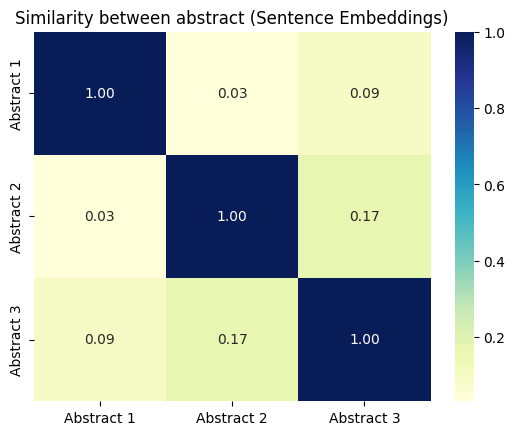

In [ ]:
#Menggunakan Sentence Embeddings
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(documents, convert_to_tensor=True)
similarity_matrix = util.cos_sim(embeddings, embeddings)

labels = ['Abstract 1', 'Abstract 2', 'Abstract 3']
sns.heatmap(similarity_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="YlGnBu", fmt=".2f")

df = pd.DataFrame(
    doc_term_matrix,
    columns=count_vectorizer.get_feature_names_out(),
    index=labels
)

print("\n=== Document-Term Matrix using CountVectorizer ===")
print(df)

plt.title("Similarity between abstract (Sentence Embeddings)")
plt.show()